# AI vs Human-Generated Image Classification

### I. Project Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from PIL import Image
from tqdm import tqdm

In [2]:
DATASET_FOLDER = "../data"
DATASET_IMAGE_FOLDER = f"{DATASET_FOLDER}/train_data"
DATASET_CSV_PATH = f"{DATASET_FOLDER}/train.csv"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64

TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

UNFREEZE_LAYERS = 1

RANDOM_SEED = 42
EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {DEVICE}")
NUM_WORKERS = 0

RESUME_TRAINING = False
BEST_CHECKPOINT_PATH = "../models/convnext_best.pth"
FINAL_MODEL_PATH = "../models/convnext_final.pth"

Using device cuda


### II. Data Preparation and Preprocessing

In [3]:
df = pd.read_csv(DATASET_CSV_PATH)
df.head(5)

,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1


```Label```:
- 0: Human Generated Image
- 1: AI Generated Image

In [4]:
df = df[["file_name", "label"]]

In [5]:
class ImageDataset(Dataset):
    def __init__(self, df, transform = None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        image_path = os.path.join(DATASET_FOLDER, self.df.iloc[index, 0])
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = self.df.iloc[index, 1]
        return image, label

In [6]:
train_df, temp_df = train_test_split(df, train_size = TRAIN_SIZE, random_state = RANDOM_SEED, stratify = df["label"])
val_df, test_df = train_test_split(temp_df, train_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE), random_state = RANDOM_SEED, stratify = temp_df["label"])

In [7]:
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale = (0.9, 1.0)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1, hue = 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
])

In [8]:
train_dataset = ImageDataset(train_df, transform = train_transform)
val_dataset = ImageDataset(val_df, transform = val_transform)
test_dataset = ImageDataset(test_df, transform = val_transform)

In [9]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = NUM_WORKERS)

### III. Modeling

In [10]:
model = convnext_tiny(weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False

for layer in list(model.children())[-UNFREEZE_LAYERS:]:
    for param in layer.parameters():
        param.requires_grad = True

in_features = model.classifier[2].in_features

model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p = 0.3),
    nn.Linear(512, 2)
)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = LEARNING_RATE)

In [12]:
start_epoch = 0
best_val_loss = float("inf")
no_improvement_epochs = 0

In [13]:
if RESUME_TRAINING and os.path.exists(BEST_CHECKPOINT_PATH):
    checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location = DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    print(f"Resumed training from epoch {start_epoch} with best validation loss {best_val_loss:.4f}")
else:
    print("Starting training from scratch")

model = model.to(DEVICE)

Starting training from scratch


In [14]:
def train_one_epoch(model, data_loader, optimizer, criterion, epoch, device = DEVICE):
    model.train()

    running_loss, correct, total = 0.0, 0, 0
    all_predictions, all_labels = [], []

    progress_bar = tqdm(data_loader, desc = f"Epoch {epoch + 1}", unit = "batch")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, prediction = torch.max(outputs, 1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(prediction.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    epoch_f1 = f1_score(all_labels, all_predictions, average = "macro")
    return epoch_loss, epoch_accuracy, epoch_f1


In [10]:
def evaluate(model, data_loader, criterion, device = DEVICE):
    model.eval()

    running_loss, correct, total = 0.0, 0, 0
    all_predictions, all_labels = [], []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, prediction = torch.max(outputs, 1)
            correct += (prediction == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(prediction.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    epoch_f1 = f1_score(all_labels, all_predictions, average = "macro")
    return epoch_loss, epoch_accuracy, epoch_f1    

In [16]:
try:
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    for epoch in range(start_epoch, EPOCHS):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, epoch)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion) 

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch [{epoch + 1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}, Train F1-Score: {train_f1:.4f}, Val F1-Score: {val_f1:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improvement_epochs = 0

            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss                
            }, BEST_CHECKPOINT_PATH)
        else:
            no_improvement_epochs += 1
            if no_improvement_epochs >= EARLY_STOPPING_PATIENCE:
                print("Early stopping triggered")
                break

        torch.save({
            "model_sate_dict": model.state_dict()
        }, FINAL_MODEL_PATH)

except KeyboardInterrupt:
    print("Training interrupted. Best checkpoint is already saved.")

print(f"\Final model weights saved to {FINAL_MODEL_PATH}")
print(f"Best val_loss={best_val_loss:.4f} (checkpoint at {BEST_CHECKPOINT_PATH})")

Epoch 1: 100%|██████████| 875/875 [14:01<00:00,  1.04batch/s, loss=0.0978]


Epoch [1/10], Train Loss: 0.2525, Val Loss: 0.1405, Train Accuracy: 0.8987, Val Accuracy: 0.9480, Train F1-Score: 0.8987, Val F1-Score: 0.9479


Epoch 2: 100%|██████████| 875/875 [08:42<00:00,  1.68batch/s, loss=0.2619]


Epoch [2/10], Train Loss: 0.1582, Val Loss: 0.1121, Train Accuracy: 0.9383, Val Accuracy: 0.9592, Train F1-Score: 0.9383, Val F1-Score: 0.9592


Epoch 3: 100%|██████████| 875/875 [08:42<00:00,  1.67batch/s, loss=0.2867]


...

Epoch [7/10], Train Loss: 0.1039, Val Loss: 0.0895, Train Accuracy: 0.9594, Val Accuracy: 0.9667, Train F1-Score: 0.9594, Val F1-Score: 0.9667


Epoch 8: 100%|██████████| 875/875 [08:45<00:00,  1.67batch/s, loss=0.3146]


Epoch [8/10], Train Loss: 0.0950, Val Loss: 0.0846, Train Accuracy: 0.9632, Val Accuracy: 0.9679, Train F1-Score: 0.9632, Val F1-Score: 0.9679


Epoch 9: 100%|██████████| 875/875 [08:44<00:00,  1.67batch/s, loss=0.2172]


Epoch [9/10], Train Loss: 0.0949, Val Loss: 0.0882, Train Accuracy: 0.9627, Val Accuracy: 0.9661, Train F1-Score: 0.9627, Val F1-Score: 0.9660
Early stopping triggered
\Final model weights saved to ../models/convnext_final.pth
Best val_loss=0.0790 (checkpoint at ../models/convnext_best.pth)


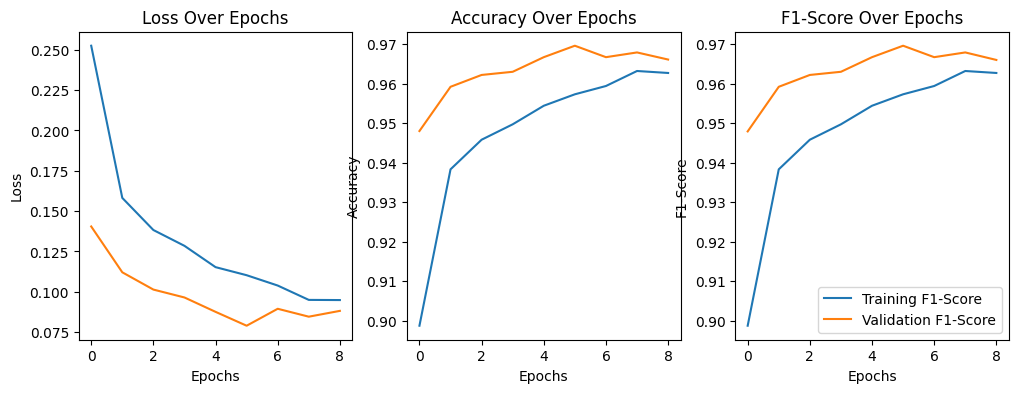

In [27]:
plt.figure(3, figsize = (12, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label = "Training Loss")
plt.plot(history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")

plt.subplot(1, 3, 2)
plt.plot(history["train_acc"], label = "Training Accuracy")
plt.plot(history["val_acc"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")

plt.subplot(1, 3, 3)
plt.plot(history["train_f1"], label = "Training F1-Score")
plt.plot(history["val_f1"], label = "Validation F1-Score")
plt.xlabel("Epochs")
plt.ylabel("F1-Score")
plt.title("F1-Score Over Epochs")

plt.legend()
plt.show()

### IV. Evaluation

In [ ]:
model = convnext_tiny(weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[2].in_features

model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p = 0.3),
    nn.Linear(512, 2)
)

best_checkpoint = torch.load(BEST_CHECKPOINT_PATH)
model.load_state_dict(best_checkpoint["model_state_dict"])
model = model.to(DEVICE)

In [12]:
criterion = nn.CrossEntropyLoss()

In [18]:
model.eval()

all_predictions, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, prediction = torch.max(outputs, 1)
        all_predictions.extend(prediction.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [21]:
print(confusion_matrix(all_labels, all_predictions))

[[5752  245]
 [ 122 5874]]


In [22]:
print(classification_report(all_labels, all_predictions))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5997
           1       0.96      0.98      0.97      5996

    accuracy                           0.97     11993
   macro avg       0.97      0.97      0.97     11993
weighted avg       0.97      0.97      0.97     11993



In [23]:
print(roc_auc_score(all_labels, all_predictions))

0.9693996709273027
